In [ ]:
# Install all required libraries
!pip install pyLDAvis gensim bs4 nltk spacy scikit-learn pandas matplotlib seaborn rouge-score -q
!pip install wordcloud textblob sentence-transformers langdetect google-cloud-translate -q
!python -m spacy download en_core_web_sm -q

# Authenticate your Google Cloud account
!gcloud auth application-default login

import re, string, warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

print('✅ All libraries installed successfully!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.goo

To resolve the `gcloud auth` error, you need to authenticate your Google Cloud account. Please run the following cell, which will open a new tab for authentication. After successful authentication, you can re-run the initial cell that failed (the one with the `set-quota-project` command).

In [ ]:
# Set the project quota
!gcloud auth application-default set-quota-project languagetranslation-jeremy


Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "languagetranslation-jeremy" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# ── IMPORTS — run this after any runtime restart
import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import transformers as tr
import torch as trh
import gensim as gm
import requests as rq
import json as js
import spacy
import plotly as plty
import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

from bs4 import BeautifulSoup

# from google.colab import auth; auth.authenticate_user()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/newsbot-translation.json"
nlp = spacy.load('en_core_web_sm')

from google.cloud import translate_v2 as translate

client = translate.Client()
result = client.translate(
    "Hola, ¿cómo estás?",
    target_language="en"
)

print(result["translatedText"])

# Add custom EntityRuler to recognize specific product names
ruler = nlp.add_pipe('entity_ruler', before='ner')
patterns = [
    {"label": "PRODUCT", "pattern": [{"LOWER": "iphone"}, {"IS_DIGIT": True}]}
]
ruler.add_patterns(patterns)

plt.style.use('seaborn-v0_8-darkgrid')
print('✅ All imports successful!')

warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

Hello how are you?
✅ All imports successful!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# Design your system architecture
class NewsBot2Config:
    """Configuration management for NewsBot 2.0
    Defines all system settings here."""

    def __init__(self):
        # API keys and endpoints
        self.api_key = None  # Placeholder for external API keys if needed

        # Model parameters
        self.tfidf_max_features = 5000
        self.tfidf_ngram_range = (1, 2)
        self.classifier_params = {
            'Naive Bayes': {'alpha': 0.1},
            'Logistic Regression': {'max_iter': 1000, 'C': 1.0, 'random_state': 42},
            'Linear SVM': {'C': 1.0, 'max_iter': 2000, 'random_state': 42},
            'Random Forest': {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}
        }

        # File paths and directories
        self.processed_data_path = 'newsbot_dataset.csv'
        self.model_path = 'newsbot_model.pkl'

        # Processing limits and thresholds
        self.ner_text_limit = 1200        # Max characters for NER processing
        self.sentiment_text_limit = 1000  # Max characters for sentiment analysis
        self.pos_sample_size = 150        # Number of articles to sample for POS analysis
        self.ner_sample_size = 80         # Number of articles to sample for NER analysis

warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

class NewsBot2System:
    """Main system orchestrator for NewsBot 2.0"""

    def __init__(self, config):
        self.config = config
        # Initialize all your system components

        # Data processing components
        self.nlp = spacy.load('en_core_web_sm')
        self.stopwords = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

        # Classification model
        try:
            with open(self.config.model_path, 'rb') as f:
                self.best_pipeline = pickle.load(f)
            print(f"Loaded best classification model from {self.config.model_path}")
        except FileNotFoundError:
            self.best_pipeline = None
            print(f"Warning: Model file not found at {self.config.model_path}. Please train the model first.")

        # Sentiment analysis (TextBlob is used in `newsbot_analyze`)
        # Not initialized explicitly here, as TextBlob objects are created per analysis.
        self.entity_types = ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY', 'NORP', 'PRODUCT']

    def _preprocess_text(self, text):
        """Helper for full text preprocessing pipeline."""
        if not isinstance(text, str) or len(text.strip()) == 0:
            return ''
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'[^\x00-\x7F]+', ' ', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = word_tokenize(text)
        tokens = [t for t in tokens if t not in self.stopwords and len(t) > 2]
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]
        return ' '.join(tokens)

    def _analyze_sentiment(self, text):
        """Helper for article-level sentiment classification."""
        blob = TextBlob(str(text)[:self.config.sentiment_text_limit])
        pol = blob.sentiment.polarity
        subj = blob.sentiment.subjectivity
        label = 'Positive' if pol > 0.1 else ('Negative' if pol < -0.1 else 'Neutral')
        return {'polarity': round(pol, 4), 'subjectivity': round(subj, 4), 'sentiment_label': label}

    def _extract_entities(self, text):
        """Helper for extracting named entities using spaCy."""
        doc = self.nlp(str(text)[:self.config.ner_text_limit])
        entities = {e: [] for e in self.entity_types}
        for ent in doc.ents:
            if ent.label_ in self.entity_types:
                entities[ent.label_].append(ent.text.strip())
        return {k: list(dict.fromkeys(v)) for k, v in entities.items() if v}

    def analyze_article(self, article_text):
        """Implement comprehensive article analysis.
        This should return all the insights your system can generate.
        """
        if not self.best_pipeline:
            return {"error": "Classification model not loaded. Please train the model first."}

        processed_text = self._preprocess_text(article_text)
        category = self.best_pipeline.predict([processed_text])[0]
        sentiment = self._analyze_sentiment(article_text)
        entities = self._extract_entities(article_text)

        return {
            'category': category,
            'sentiment': sentiment,
            'entities': entities,
            'processed_text_length': len(processed_text.split()),
            'original_text_length': len(article_text.split())
        }

    def process_query(self, user_query):
        """Handle natural language queries from users (placeholder)."""
        # TODO: Implement query processing logic, e.g., search, summary generation
        return f"Query received: '{user_query}'. This feature is under development."

    def generate_insights(self, articles):
        """Generate high-level insights from multiple articles (placeholder)."""
        # TODO: Implement aggregation and comparison across multiple articles
        return "Insights generation feature is under development."

# Initialize your system | Code Below
config = NewsBot2Config()
newsbot = NewsBot2System(config)
print("🏗️ System architecture Complete!")
print("💡 Next: Start implementing individual components")

🏗️ System architecture Complete!
💡 Next: Start implementing individual components


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🔍 Topic Modeling and Discovery
# TODO: Implement topic modeling for content discovery
class TopicDiscoveryEngine:
  """
  Advanced topic modeling for discovering themes and trends
  """
  def __init__(self, n_topics=10, method='lda'):
    # Initialize topic modeling components
    self.n_topics = n_topics
    self.method = method # Currently only LDA implemented
    self.dictionary = None
    self.model = None
    self.corpus = None # Store corpus for visualization
    self.stopwords = set(stopwords.words('english'))
    self.lemmatizer = WordNetLemmatizer()

  def _preprocess_for_topic_modeling(self, text):
    """Helper for text preprocessing specific to topic modeling."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # Remove non-ASCII chars
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    # Remove stopwords, single character tokens, and lemmatize
    tokens = [self.lemmatizer.lemmatize(t) for t in tokens if t not in self.stopwords and len(t) > 1]
    return tokens

  def fit_topics(self, documents):
    """Discover topics in a collection of documents using LDA."""
    if not documents:
      print("No documents provided for topic modeling.")
      return

    print(f"Preprocessing {len(documents)} documents for topic modeling...")
    processed_docs = [self._preprocess_for_topic_modeling(doc) for doc in documents]
    processed_docs = [doc for doc in processed_docs if doc] # Filter out empty docs

    if not processed_docs:
        print("No valid documents left after preprocessing.")
        return

    print("Creating dictionary and corpus...")
    self.dictionary = gm.corpora.Dictionary(processed_docs)
    # Filter out words that appear in less than no_below documents or in more than no_above fraction of documents
    self.dictionary.filter_extremes(no_below=1, no_above=0.5) # Changed no_below from 5 to 1
    corpus = [self.dictionary.doc2bow(doc) for doc in processed_docs]
    self.corpus = corpus # Store corpus for visualization

    print(f"Training LDA model with {self.n_topics} topics...")
    if self.method == 'lda':
      # Using Latent Dirichlet Allocation (LDA)
      self.model = gm.models.LdaModel(corpus, num_topics=self.n_topics, id2word=self.dictionary, passes=15)
    else:
      raise NotImplementedError(f"Topic modeling method '{self.method}' not implemented.")

    print("Topic modeling complete. Top topics:")
    for idx, topic in self.model.print_topics(-1):
      print(f"Topic: {idx} \nWords: {topic}")

  def get_article_topics(self, article_text):
    """Get topic distribution for a single article."""
    if not self.model or not self.dictionary:
      print("Model not trained. Please run fit_topics first.")
      return None

    processed_text = self._preprocess_for_topic_modeling(article_text)
    if not processed_text:
        return []

    bow = self.dictionary.doc2bow(processed_text)
    topic_distribution = self.model.get_document_topics(bow)
    return sorted(topic_distribution, key=lambda x: x[1], reverse=True)

  def track_topic_trends(self, articles_with_dates):
    """Analyze how topics change over time (basic dominant topic per day)."""
    if not self.model or not self.dictionary:
        print("Model not trained. Please run fit_topics first.")
        return

    # Group articles by date
    articles_by_date = {}
    for date_str, article_text in articles_with_dates:
        # Assuming date_str is in 'YYYY-MM-DD' format or similar
        try:
            date = pd.to_datetime(date_str).date()
        except ValueError:
            print(f"Skipping article due to invalid date format: {date_str}")
            continue

        if date not in articles_by_date:
            articles_by_date[date] = []
        articles_by_date[date].append(article_text)

    print("Analyzing topic trends over time...")
    trend_data = []
    for date in sorted(articles_by_date.keys()):
        daily_articles = articles_by_date[date]
        daily_topic_distributions = []
        for article_text in daily_articles:
            topic_dist = self.get_article_topics(article_text)
            if topic_dist:
                daily_topic_distributions.append(topic_dist)

        if daily_topic_distributions:
            # Aggregate topic distributions for the day: sum up scores for each topic across articles
            aggregated_topics = Counter()
            for dist_list in daily_topic_distributions:
                for topic_id, score in dist_list:
                    aggregated_topics[topic_id] += score

            if aggregated_topics:
                most_dominant_topic_id, _ = aggregated_topics.most_common(1)[0]
                trend_data.append((date, most_dominant_topic_id))
                print(f"Date: {date}, Most Dominant Topic ID: {most_dominant_topic_id}")
            else:
                print(f"Date: {date}, No dominant topics identified for articles.")
        else:
            print(f"Date: {date}, No articles with identifiable topics.")

    print("Tracking topic trends complete (basic dominant topic per day shown).")
    # Further visualization or analysis of trend_data could be added here.

  def visualize_topics(self):
    """Create interactive topic visualizations using pyLDAvis and word clouds."""
    if not self.model or not self.dictionary or not self.corpus:
      print("Model, dictionary, or corpus not available. Please run fit_topics first.")
      return

    # 1. pyLDAvis visualization
    print("Generating pyLDAvis visualization (may take a moment)...")
    try:
        vis = gensim_models.prepare(self.model, self.corpus, self.dictionary, mds='mmds')
        pyLDAvis.display(vis)
        print("pyLDAvis visualization displayed.")
    except Exception as e:
        print(f"Could not generate pyLDAvis visualization: {e}")

    # 2. Word clouds for each topic
    print("Generating word clouds for each topic...")
    for i, topic in self.model.show_topics(formatted=False, num_topics=self.n_topics, num_words=20):
        topic_words = {word: prob for word, prob in topic}
        wc = WordCloud(background_color="white", max_words=50, width=800, height=400)
        wc.generate_from_frequencies(topic_words)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Topic {i} Word Cloud")
        plt.show()
    print("Word clouds for topics displayed.")

# TODO: Test your topic modeling
topic_engine = TopicDiscoveryEngine()
print("🔍 Topic discovery engine ready for implementation!")

🔍 Topic discovery engine ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🎭 Advanced Sentiment Analysis
# TODO: Implement sentiment analysis with temporal tracking
class SentimentEvolutionTracker:
  """
  Advanced sentiment analysis with temporal and contextual understanding
  """
  def __init__(self):
    # Initialize sentiment analysis components
    # TextBlob is already imported, so we just need to use it.
    self.sentiment_history = [] # To store sentiment data for temporal tracking

  def analyze_sentiment(self, article_text):
    """
    Comprehensive sentiment analysis using TextBlob.
    Returns: Overall sentiment (positive/negative/neutral), polarity, and subjectivity.
    """
    if not isinstance(article_text, str) or len(article_text.strip()) == 0:
      return {
          'polarity': 0.0, 'subjectivity': 0.0, 'sentiment_label': 'Neutral'
      }

    blob = TextBlob(article_text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    if polarity > 0.1:
      sentiment_label = 'Positive'
    elif polarity < -0.1:
      sentiment_label = 'Negative'
    else:
      sentiment_label = 'Neutral'

    return {
        'polarity': round(polarity, 4),
        'subjectivity': round(subjectivity, 4),
        'sentiment_label': sentiment_label
    }

  def track_sentiment_over_time(self, articles_with_dates):
    """
    Analyze sentiment trends over time.
    articles_with_dates: List of tuples (date_str, article_text)
    """
    if not articles_with_dates:
      print("No articles provided for sentiment tracking.")
      return []

    daily_sentiments = {}
    for date_str, article_text in articles_with_dates:
      try:
        date = pd.to_datetime(date_str).date()
      except ValueError:
        print(f"Skipping article due to invalid date format: {date_str}")
        continue

      sentiment_result = self.analyze_sentiment(article_text)
      if date not in daily_sentiments:
        daily_sentiments[date] = {'polarities': [], 'subjectivities': []}
      daily_sentiments[date]['polarities'].append(sentiment_result['polarity'])
      daily_sentiments[date]['subjectivities'].append(sentiment_result['subjectivity'])

    sentiment_timeline = []
    for date in sorted(daily_sentiments.keys()):
      avg_polarity = np.mean(daily_sentiments[date]['polarities'])
      avg_subjectivity = np.mean(daily_sentiments[date]['subjectivities'])
      if avg_polarity > 0.1:
        sentiment_label = 'Positive'
      elif avg_polarity < -0.1:
        sentiment_label = 'Negative'
      else:
        sentiment_label = 'Neutral'
      sentiment_timeline.append({
          'date': date,
          'avg_polarity': round(avg_polarity, 4),
          'avg_subjectivity': round(avg_subjectivity, 4),
          'avg_sentiment_label': sentiment_label
      })

    self.sentiment_history = sentiment_timeline
    print("Sentiment tracking over time complete.")
    return sentiment_timeline

  def detect_sentiment_anomalies(self, sentiment_timeline):
    """
    Identify unusual sentiment patterns based on polarity deviation.
    Args:
        sentiment_timeline (list): List of dicts with daily sentiment data (incl. 'avg_polarity').
        threshold_std (int/float): Number of standard deviations from the mean to consider an anomaly.
    Returns:
        list: A list of dictionaries, each representing an anomalous day's sentiment.
    """
    if not sentiment_timeline:
        print("No sentiment timeline data provided for anomaly detection.")
        return []

    polarities = [item['avg_polarity'] for item in sentiment_timeline]
    if len(polarities) < 2: # Need at least two data points to calculate std dev
        print("Not enough data points to detect anomalies.")
        return []

    mean_polarity = np.mean(polarities)
    std_polarity = np.std(polarities)

    anomalies = []
    for item in sentiment_timeline:
        if abs(item['avg_polarity'] - mean_polarity) > std_polarity:
            anomalies.append({
                'date': item['date'],
                'avg_polarity': item['avg_polarity'],
                'deviation_from_mean': round(item['avg_polarity'] - mean_polarity, 4),
                'anomaly_type': 'Extreme Positive' if item['avg_polarity'] > mean_polarity else 'Extreme Negative'
            })

    if anomalies:
        print(f"Detected {len(anomalies)} sentiment anomalies.")
    else:
        print("No significant sentiment anomalies detected.")

    return anomalies

# TODO: Test your sentiment tracker
sentiment_tracker = SentimentEvolutionTracker()
print("🎭 Sentiment evolution tracker ready for implementation!")

🎭 Sentiment evolution tracker ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🕸️ Entity Relationship Mapping
# TODO: Implement advanced entity recognition and relationship mapping
class EntityRelationshipMapper:
  """
  Advanced NER with relationship extraction and network analysis
  """
  def __init__(self, nlp_model):
    # Initialize NER and relationship extraction components
    self.nlp = nlp_model # Use the passed nlp model
    self.knowledge_graph = {}

  def extract_entities(self, article_text):
    """
    Extract and classify entities from the article text.
    Returns: A dictionary where keys are entity types and values are lists of unique entities.
    """
    if not isinstance(article_text, str) or not article_text.strip():
        return {}

    doc = self.nlp(article_text)
    entities_by_type = {}
    for ent in doc.ents:
        label = ent.label_
        text = ent.text.strip()
        if label not in entities_by_type:
            entities_by_type[label] = set() # Use set to store unique entities
        entities_by_type[label].add(text)
    return {label: list(entities) for label, entities in entities_by_type.items()}


  def extract_relationships(self, article_text):
    """
    Extract relationships between entities within the article text.
    This implementation uses a simple heuristic: if two entities are in the same sentence,
    and a verb appears between them, that verb is considered a potential relationship.
    Returns: A list of dictionaries, each representing a relationship.
    """
    if not isinstance(article_text, str) or not article_text.strip():
        return []

    doc = self.nlp(article_text)
    relationships = []

    for sentence in doc.sents:
        entities_in_sentence = [(ent.text.strip(), ent.label_, ent.start_char, ent.end_char) for ent in sentence.ents]
        if len(entities_in_sentence) < 2:
            continue

        # Sort entities by their start_char to process them in order
        entities_in_sentence.sort(key=lambda x: x[2])

        for i in range(len(entities_in_sentence)):
            for j in range(i + 1, len(entities_in_sentence)):
                ent1_text, ent1_label, ent1_start, ent1_end = entities_in_sentence[i]
                ent2_text, ent2_label, ent2_start, ent2_end = entities_in_sentence[j]

                # Extract the text span between the two entities
                # Adjust start/end char relative to sentence start
                span_start_in_sent = ent1_end - sentence.start_char
                span_end_in_sent = ent2_start - sentence.start_char
                span_between_entities = sentence.text[span_start_in_sent : span_end_in_sent].strip()


                # A very basic heuristic: look for verbs in the span between entities
                # This is a simplification; a full dependency parse would be more accurate.
                between_doc = self.nlp(span_between_entities)
                potential_relations = [token.lemma_ for token in between_doc if token.pos_ == 'VERB']

                # If we found any verbs, use the first one as a simple relationship
                if potential_relations:
                    relationship = potential_relations[0]
                    relationships.append({
                        'head': ent1_text,
                        'head_type': ent1_label,
                        'relation': relationship,
                        'tail': ent2_text,
                        'tail_type': ent2_label,
                        'sentence': sentence.text
                    })
                else:
                    # If no verb, consider a generic co-occurrence relation
                    relationships.append({
                        'head': ent1_text,
                        'head_type': ent1_label,
                        'relation': 'co-occurs_with',
                        'tail': ent2_text,
                        'tail_type': ent2_label,
                        'sentence': sentence.text
                    })

    return relationships

  def build_knowledge_graph(self, articles):
    """
    Build a simple knowledge graph from multiple articles.
    The graph is stored as a dictionary where keys are entities and values are
    lists of (related_entity, relationship) tuples.
    """
    self.knowledge_graph = {} # Reset graph for new build

    for article_text in articles:
        relationships = self.extract_relationships(article_text)
        for rel in relationships:
            head = rel['head']
            tail = rel['tail']
            relation = rel['relation']

            if head not in self.knowledge_graph:
                self.knowledge_graph[head] = []
            if tail not in self.knowledge_graph:
                self.knowledge_graph[tail] = []

            # Add directional relationship
            self.knowledge_graph[head].append({'target': tail, 'relation': relation, 'source_article_sentence': rel.get('sentence')})
            # Add inverse relationship for bi-directional search
            self.knowledge_graph[tail].append({'target': head, 'relation': f'inverse_{relation}', 'source_article_sentence': rel.get('sentence')})

    print(f"Knowledge graph built with {len(self.knowledge_graph)} unique entities and their connections.")
    return self.knowledge_graph

  def find_entity_connections(self, entity1, entity2):
    """
    Find connections (paths) between two entities in the knowledge graph using BFS.
    Returns: A list of paths found, or an empty list if no connection.
    """
    if entity1 not in self.knowledge_graph or entity2 not in self.knowledge_graph:
        print(f"One or both entities ('{entity1}', '{entity2}') not found in the knowledge graph.")
        return []

    if entity1 == entity2:
        return [[entity1]]

    queue = [(entity1, [entity1])] # (current_node, path)
    visited = {entity1}
    paths = []

    # Limit search depth to prevent extremely long paths and infinite loops in cyclic graphs
    MAX_DEPTH = 5
    while queue:
        current_node, path = queue.pop(0)

        if len(path) > MAX_DEPTH + 1: # +1 because path includes the current node
            continue

        for connection in self.knowledge_graph.get(current_node, []):
            neighbor = connection['target']
            relation = connection['relation']
            connection_info = (relation, neighbor)

            if neighbor == entity2:
                paths.append(path + [connection_info])

            # For finding *some* paths (not necessarily all disjoint paths or shortest paths if cycles exist),
            # a simple `visited` set per BFS run is sufficient to prevent infinite loops in cycles.
            if neighbor not in visited: # This prevents re-visiting nodes within a single BFS path
                visited.add(neighbor)
                queue.append((neighbor, path + [connection_info]))

    if not paths:
        print(f"No direct or indirect connections found between '{entity1}' and '{entity2}' within {MAX_DEPTH} hops.")
    return paths

# Instantiate the entity mapper, passing the globally available nlp object
entity_mapper = EntityRelationshipMapper(nlp)
print("🕸️ Entity relationship mapper ready for implementation!")

🕸️ Entity relationship mapper ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 📝 Intelligent Text Summarization
class IntelligentSummarizer:
  """
  Advanced text summarization with multiple strategies and quality control
  """
  def __init__(self):
    """
    Initializes the summarization system.
    """
    print("📝 Intelligent Summarizer initialized.")

  def _extractive_summarize_tfidf(self, article_text, ratio):
    """
    Helper method for extractive summarization using TF-IDF.
    """
    if not article_text.strip():
      return ""

    sentences = sent_tokenize(article_text)
    if not sentences:
      return ""

    # Use TfidfVectorizer directly for sentence scoring
    vectorizer = TfidfVectorizer(stop_words='english')
    try:
      tfidf_matrix = vectorizer.fit_transform(sentences)
    except ValueError:
      # Handle cases where all sentences might be stopwords or too short
      return ' '.join(sentences[:max(1, int(len(sentences) * ratio))])

    # Calculate sentence scores (sum of TF-IDF scores for words in each sentence)
    sentence_scores = tfidf_matrix.sum(axis=1)

    # Get top sentences based on ratio
    num_sentences = len(sentences)
    top_n_sentences = max(1, int(num_sentences * ratio))

    # Get indices of top scored sentences
    # Use .A1 to convert sparse matrix to 1D numpy array if it's a matrix
    # If it's a numpy array directly, skip .A1
    if hasattr(sentence_scores, 'A1'):
        ranked_sentences_indices = sentence_scores.A1.argsort()[-top_n_sentences:][::-1]
    else:
        ranked_sentences_indices = sentence_scores.argsort()[-top_n_sentences:][::-1]

    # Sort sentences by their original order
    sorted_indices = sorted(ranked_sentences_indices)
    summary_sentences = [sentences[i] for i in sorted_indices]

    return ' '.join(summary_sentences)

  def summarize_article(self, article_text, summary_type='balanced'):
    """
    Generates an extractive summary of a single article.
    Parameters:
    - article_text (str): The text of the article to summarize.
    - summary_type (str): 'brief', 'balanced', or 'detailed' to control summary length.
    Returns:
    - str: The generated summary.
    """
    if not isinstance(article_text, str) or not article_text.strip():
      return ""

    # Define ratios based on summary_type
    if summary_type == 'brief':
      ratio = 0.15
    elif summary_type == 'detailed':
      ratio = 0.5
    else: # 'balanced'
      ratio = 0.3

    try:
      summary = self._extractive_summarize_tfidf(article_text, ratio=ratio)
      if not summary and article_text:
          # Fallback for very short texts where custom summarizer might return empty
          sentences = sent_tokenize(article_text)
          summary = ' '.join(sentences[:max(1, int(len(sentences) * ratio))])
      return summary.strip()
    except Exception as e:
      # Handle cases where summarizer might fail
      print(f"Summarization failed: {e}. Returning first few sentences as fallback.")
      sentences = sent_tokenize(article_text)
      return ' '.join(sentences[:max(1, int(len(sentences) * ratio))]).strip()

  def summarize_multiple_articles(self, articles, focus_topic=None):
    """
    Creates a unified summary from multiple articles.
    For simplicity, this concatenates articles and then summarizes the combined text.
    A more advanced implementation would involve multi-document summarization techniques.
    Parameters:
    - articles (list): A list of article texts (strings).
    - focus_topic (str, optional): A keyword or phrase to guide summarization (not implemented in this basic version).
    Returns:
    - str: The unified summary.
    """
    if not articles:
      return ""

    combined_text = " ".join(articles)
    # Can pass a higher ratio for multi-document summary if desired
    unified_summary = self.summarize_article(combined_text, summary_type='balanced')
    return unified_summary

  def generate_headlines(self, article_text):
    """
    Generates a compelling headline for an article.
    For a basic implementation, this returns the first sentence of the article.
    Parameters:
    - article_text (str): The text of the article.
    Returns:
    - str: The generated headline.
    """
    if not isinstance(article_text, str) or not article_text.strip():
      return ""

    sentences = sent_tokenize(article_text)
    if sentences:
      # Return the first sentence as a simple headline
      return sentences[0].strip()
    return ""

  def assess_summary_quality(self, original_text, summary):
    """
    Evaluates summary quality using metrics like ROUGE scores.
    This is a placeholder for a more robust evaluation system.
    Parameters:
    - original_text (str): The original full text.
    - summary (str): The generated summary.
    Returns:
    - dict: A dictionary containing quality assessment metrics.
    """
    metrics = {
        'original_length': len(word_tokenize(original_text)),
        'summary_length': len(word_tokenize(summary)),
        'compression_ratio': round(len(word_tokenize(summary)) / len(word_tokenize(original_text)) if len(word_tokenize(original_text)) > 0 else 0, 2)
    }
    # To implement ROUGE, you would typically use a library like `rouge_score`.
    # Example (concept only):
    # from rouge_score import rouge_scorer
    # scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    # scores = scorer.score(original_text, summary)
    # metrics.update({'rouge1_fmeasure': scores['rouge1'].fmeasure, ...})

    return metrics

# Instantiate and confirm the summarizer is ready
summarizer = IntelligentSummarizer()
print("📝 Intelligent summarizer ready for implementation!")

📝 Intelligent Summarizer initialized.
📝 Intelligent summarizer ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🔍 Semantic Search and Similarity
class SemanticSearchEngine:
  """
  Advanced semantic search using embeddings and similarity matching
  """
  def __init__(self, model_name='all-MiniLM-L6-v2'):
    """
    Initializes the semantic search engine with a pre-trained sentence transformer model.
    """
    try:
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_name)
        print(f"Loaded SentenceTransformer model: {model_name}")
    except ImportError:
        print("Error: sentence-transformers library not found. Please install it using !pip install sentence-transformers")
        self.model = None
    except Exception as e:
        print(f"Error loading SentenceTransformer model: {e}")
        self.model = None

    self.corpus_embeddings = None # To store embeddings of a corpus of documents

  def encode_documents(self, documents):
    """
    Convert documents to semantic embeddings using the loaded model.
    Returns: A numpy array of embeddings.
    """
    if self.model is None:
        print("SentenceTransformer model not loaded. Cannot encode documents.")
        return None
    print(f"Encoding {len(documents)} documents...")
    embeddings = self.model.encode(documents, show_progress_bar=True)
    print("Documents encoded.")
    return embeddings

  def find_similar_articles(self, query_embedding, corpus_embeddings, top_k=5):
    """
    Find semantically similar articles using cosine similarity.
    Args:
        query_embedding: Embedding of the query article/text.
        corpus_embeddings: Embeddings of the corpus of articles to search within.
        top_k: Number of most similar articles to return.
    Returns:
        List of (index, similarity_score) tuples for the top_k similar articles.
    """
    if query_embedding is None or corpus_embeddings is None:
        print("Embeddings are missing. Cannot find similar articles.")
        return []

    from sklearn.metrics.pairwise import cosine_similarity
    similarities = cosine_similarity(query_embedding.reshape(1, -1), corpus_embeddings)[0]
    top_indices = similarities.argsort()[-top_k:][::-1]
    results = [(idx, similarities[idx]) for idx in top_indices]
    return results

  def semantic_search(self, query_text, article_corpus, corpus_embeddings=None, top_k=5):
    """
    Search articles using a natural language query.
    Args:
        query_text: The natural language query string.
        article_corpus: The list of original article texts.
        corpus_embeddings: Pre-computed embeddings of the article_corpus. If None, they will be computed.
        top_k: Number of most relevant articles to return.
    Returns:
        List of (article_text, similarity_score) tuples for the top_k relevant articles.
    """
    if self.model is None:
        print("SentenceTransformer model not loaded. Cannot perform semantic search.")
        return []

    if corpus_embeddings is None:
        print("Corpus embeddings not provided, encoding corpus...")
        corpus_embeddings = self.encode_documents(article_corpus)
        if corpus_embeddings is None:
            return []

    query_embedding = self.model.encode([query_text])[0]
    similar_indices_scores = self.find_similar_articles(query_embedding, corpus_embeddings, top_k)

    results = []
    for idx, score in similar_indices_scores:
        results.append((article_corpus[idx], score))
    return results

  def cluster_similar_content(self, articles, n_clusters=3):
    """
    Group articles by semantic similarity using K-Means clustering.
    Args:
        articles: List of article texts.
        n_clusters: The number of clusters to form.
    Returns:
        A dictionary where keys are cluster IDs and values are lists of article texts.
    """
    if self.model is None:
        print("SentenceTransformer model not loaded. Cannot cluster content.")
        return {}

    if not articles:
        print("No articles provided for clustering.")
        return {}

    embeddings = self.encode_documents(articles)
    if embeddings is None:
        return {}

    from sklearn.cluster import KMeans
    print(f"Clustering {len(articles)} articles into {n_clusters} clusters...")
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans_model.fit(embeddings)
    cluster_labels = kmeans_model.labels_

    clustered_articles = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(cluster_labels):
        clustered_articles[label].append(articles[i])

    print("Clustering complete.")
    return clustered_articles

# Instantiate the search engine
search_engine = SemanticSearchEngine()
print("🔍 Semantic search engine ready for implementation!")

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded SentenceTransformer model: all-MiniLM-L6-v2
🔍 Semantic search engine ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 💡 Content Enhancement and Insights
class ContentEnhancer:
  """
  Advanced content analysis and enhancement system
  """
  def __init__(self, nlp_model, entity_mapper_instance, summarizer_instance):
    # Initialize content enhancement components
    self.nlp = nlp_model
    self.entity_mapper = entity_mapper_instance
    self.summarizer = summarizer_instance
    print("💡 Content enhancer initialized.")

  def enhance_article(self, article_text):
    """
    Add valuable context and insights to articles.
    For this basic implementation, it identifies key entities and suggests further research.
    """
    if not isinstance(article_text, str) or not article_text.strip():
        return "No content to enhance."

    extracted_entities = self.entity_mapper.extract_entities(article_text)
    enhancements = f"Original Article:\n{article_text}\n\n"
    enhancements += "--- Enhanced Content ---\n"
    enhancements += "Detected Entities:\n"
    if extracted_entities:
        for ent_type, ent_list in extracted_entities.items():
            enhancements += f"  - {ent_type}: {', '.join(ent_list)}\n"
        enhancements += "\nConsider performing external lookups for these entities to gain deeper context (e.g., Wikipedia, news archives).\n"
    else:
        enhancements += "  No significant entities detected for enhancement.\n"

    # Add a simple summary as another form of enhancement
    summary = self.summarizer.summarize_article(article_text, summary_type='brief')
    if summary:
        enhancements += "\nBrief Summary:\n"
        enhancements += summary + "\n"

    return enhancements

  def generate_insights(self, articles):
    """
    Generate high-level insights from a collection of articles.
    For this basic implementation, it identifies the most frequent entities and provides a unified summary.
    """
    if not articles:
        return "No articles provided to generate insights."

    from collections import Counter
    all_entities = Counter()
    for article_text in articles:
        extracted = self.entity_mapper.extract_entities(article_text)
        for ent_type, ent_list in extracted.items():
            for ent in ent_list:
                all_entities[ent] += 1

    insights = "--- Generated Insights ---\n"
    if all_entities:
        insights += "Top 5 most frequently mentioned entities across articles:\n"
        for entity, count in all_entities.most_common(5):
            insights += f"  - {entity} (mentioned {count} times)\n"
    else:
        insights += "No significant entities found across articles.\n"

    # Provide a unified summary of all articles
    unified_summary = self.summarizer.summarize_multiple_articles(articles, summary_type='balanced')
    if unified_summary:
        insights += "\nUnified Summary of Articles:\n"
        insights += unified_summary + "\n"

    return insights

  def detect_information_gaps(self, articles, topic=None):
    """
    Identify what information might be missing.
    (This is a placeholder as it requires external knowledge/comparison).
    """
    return f"Information gap detection for topic '{topic if topic else 'N/A'}' is a complex task requiring external knowledge bases and is currently a placeholder. It would typically analyze what is *not* being said compared to a known body of information."

  def cross_reference_facts(self, article_text):
    """
    Verify facts against reliable sources.
    (This is a placeholder as it requires external, verified data sources).
    """
    return "Fact cross-referencing is a complex task requiring access to verified external sources and is currently a placeholder. It would typically involve querying trusted databases or APIs."

# Instantiate the content enhancer, passing required dependencies
enhancer = ContentEnhancer(nlp, entity_mapper, summarizer)
print("💡 Content enhancer ready for implementation!")

💡 Content enhancer initialized.
💡 Content enhancer ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🌐 Language Detection and Processing
class MultilingualProcessor:
  """
  Advanced multilingual processing with language detection and cultural context
  """
  def __init__(self, llm_client=None):
    # Initialize multilingual components
    try:
        from langdetect import detect, DetectorFactory
        # Set seed for reproducibility in langdetect
        DetectorFactory.seed = 0
        self.detect = detect
        print("langdetect successfully loaded.")


        # llm: Optional LLM client (OpenAI, Gemini, etc.)
        self.llm = llm_client
        self.nlp = spacy.load("en_core_web_sm")

        # Mini cultural idiom dictionary (extend as needed)
        self.cultural_idioms = {
            "kick the bucket": "English idiom meaning 'to die'",
            "spill the tea": "African American Vernacular English (AAVE) meaning 'share gossip'",
            "saving face": "East Asian cultural concept about preserving dignity",
            "holy cow": "South Asian cultural expression of surprise",
        }

        # Region keywords
        self.region_markers = {
            "texas": "US Southern culture",
            "london": "British cultural context",
            "lagos": "Nigerian cultural context",
            "tokyo": "Japanese cultural context",
            "havana": "Cuban cultural context",
        }

        # Historical patterns
        self.historical_patterns = [
            r"\b(19\d{2}|18\d{2}|17\d{2})\b",
            r"\b(World War I|World War II|Cold War|Civil Rights Movement)\b",
            r"\b(ancient|medieval|renaissance)\b",
        ]
    except ImportError:
        print("Error: 'langdetect' library not found. Please install it using `!pip install langdetect`")
        self.detect = None

  def detect_language(self, text):
    """
    Detect language with confidence scoring.
    This implementation uses `langdetect` which provides
    a single most probable language.
    Args:
        text (str): The input text.
    Returns:
        str: The detected language code (e.g., 'en', 'es'),
        or 'unknown' if detection fails.
    """
    if not self.detect:
        return 'error: langdetect not initialized'
    if not isinstance(text, str) or not text.strip():
        return 'no_text'
    try:
        return self.detect(text)
    except Exception as e:
        """
        langdetect can raise an exception for
        very short or ambiguous texts
        """
        return f'detection_failed: {e}'

  def translate_text(self, text, target_language='en'):
    """
    Placeholder for high-quality translation using external services.
    In a real-world scenario, this would integrate with APIs like Google Translate, DeepL, or Azure Translator.
    Args:
        text (str): The text to translate.
        target_language (str): The target language code (e.g., 'en', 'es').
    Returns:
        str: The translated text, or an error message if the service is not implemented.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    else:
      # NOTE: To use Google Cloud Translation API, you need to authenticate and enable the API.
      # For Colab, this typically involves `from google.colab import auth; auth.authenticate_user()`
      # and then `!gcloud auth application-default set-quota-project <your-project-id>`
      # Ensure `google-cloud-translate` is installed: `!pip install google-cloud-translate`
      try:
          from google.cloud import translate_v2 as translate
          translate_client = translate.Client()
          result = translate_client.translate(text, target_language=target_language)
          return result['translatedText']
      except Exception as e:
          return f"Translation failed (Google Cloud Translate API): {e}. Returning original text. Ensure API is enabled and authenticated."


  def analyze_cross_lingual(self, articles_by_language):
    """
    Compare coverage and perspectives across languages by performing topic modeling
    and sentiment analysis for each language group. This is a simplified implementation
    that creates temporary analysis engines for each language.
    Args:
        articles_by_language (dict): A dictionary where keys are language codes (str)
                                     and values are lists of article texts (list of str)
                                     for that language.
    Returns:
        dict: A dictionary summarizing the dominant topics and average sentiment
              for each language group.
    """
    if not articles_by_language:
        return "No articles provided for cross-lingual analysis."

    # Import necessary classes from other parts of the system (assuming they are defined globally)
    from collections import Counter
    # TopicDiscoveryEngine and SentimentEvolutionTracker are defined globally in other cells

    cross_lingual_summary = {}

    for lang, articles in articles_by_language.items():
        if not articles:
            cross_lingual_summary[lang] = {"status": "No articles for this language."}
            continue

        print(f"Analyzing {len(articles)} articles for language: {lang}...")

        # --- Topic Modeling for this language ---
        # Create a new instance to ensure isolated state for each language analysis
        temp_topic_engine = TopicDiscoveryEngine(n_topics=3) # Use fewer topics for a faster demo
        temp_topic_engine.fit_topics(articles)
        topics_info = []
        if temp_topic_engine.model:
            # Get top 3 topics with their top 5 words
            for idx, topic in temp_topic_engine.model.print_topics(num_words=5, num_topics=3):
                topics_info.append(f"Topic {idx}: {topic}")
        else:
            topics_info.append("Could not fit topics for this language.")

        # --- Sentiment Analysis for this language ---
        # Create a new instance to ensure isolated state
        temp_sentiment_tracker = SentimentEvolutionTracker()
        all_polarities = []
        all_subjectivities = []
        for article_text in articles:
            sentiment_result = temp_sentiment_tracker.analyze_sentiment(article_text)
            all_polarities.append(sentiment_result['polarity'])
            all_subjectivities.append(sentiment_result['subjectivity'])

        # Calculate average sentiment if articles were processed
        if all_polarities:
            avg_polarity = np.mean(all_polarities)
            avg_subjectivity = np.mean(all_subjectivities)
            if avg_polarity > 0.1:
                sentiment_label = 'Positive'
            elif avg_polarity < -0.1:
                sentiment_label = 'Negative'
            else:
                sentiment_label = 'Neutral'
        else:
            avg_polarity, avg_subjectivity, sentiment_label = 0.0, 0.0, 'Neutral'

        cross_lingual_summary[lang] = {
            "num_articles": len(articles),
            "dominant_topics": topics_info,
            "average_sentiment_polarity": round(avg_polarity, 4),
            "average_sentiment_subjectivity": round(avg_subjectivity, 4),
            "average_sentiment_label": sentiment_label
        }

    return cross_lingual_summary

  # ---------------------------------------------------------
  # Wikidata lookup for cultural grounding
  # ---------------------------------------------------------
  def wikidata_lookup(self, entity):
      url = "https://www.wikidata.org/w/api.php"
      params = {
          "action": "wbsearchentities",
          "search": entity,
          "language": "en",
          "format": "json"
      }
      try:
          r = requests.get(url, params=params).json()
          if "search" in r and len(r["search"]) > 0:
              return {
                  "label": r["search"][0].get("label"),
                  "description": r["search"][0].get("description"),
                  "wikidata_id": r["search"][0].get("id")
              }
      except:
          return None
      return None

  def extract_cultural_context(self, text, source_language):
    """
    Identify cultural references and context.
    This is a highly advanced task requiring:
    - Specialized cultural knowledge bases.
    - Advanced NLP models trained on culturally-nuanced texts.
    - Entity linking to cultural concepts, historical events, or societal norms specific to the source_language.

    This function extracts cultural context from a given text.
    Extracts:
    - Cultural idioms
    - Regional references
    - Historical context
    - Social/political nuances
    - Cultural entities (via Wikidata)
    """

    doc = self.nlp(text)

    cultural_idioms_found = []
    regional_references = []
    historical_references = []
    cultural_entities = []

    # -----------------------------
    # 1. Idiom detection
    # -----------------------------
    for idiom, meaning in self.cultural_idioms.items():
        if idiom in text.lower():
            cultural_idioms_found.append({
                "idiom": idiom,
                "meaning": meaning
            })

    # -----------------------------
    # 2. Region detection
    # -----------------------------
    for word in text.lower().split():
        if word in self.region_markers:
            regional_references.append({
                "term": word,
                "cultural_context": self.region_markers[word]
            })

    # -----------------------------
    # 3. Historical references
    # -----------------------------
    for pattern in self.historical_patterns:
        matches = re.findall(pattern, text, flags=re.IGNORECASE)
        for m in matches:
            historical_references.append(m)

    # -----------------------------
    # 4. Named Entity → Wikidata grounding
    # -----------------------------
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "GPE", "EVENT", "NORP", "ORG"]:
            wd = self.wikidata_lookup(ent.text)
            if wd:
                cultural_entities.append({
                    "text": ent.text,
                    "wikidata": wd
                })

    # -----------------------------
    # 5. Optional LLM inference
    # -----------------------------
    llm_inference = None
    if self.llm:
        prompt = f"""
        Analyze the following text for cultural context:
        Text: {text}

        Identify:
        - Cultural norms
        - Social/political nuances
        - Implicit cultural assumptions
        - Region-specific meaning

        Provide a structured JSON response.
        """
        llm_inference = self.llm(prompt)

    # -----------------------------
    # Final structured output
    # -----------------------------
    return {
        "language": source_language,
        "idioms": cultural_idioms_found,
        "regional_references": regional_references,
        "historical_references": historical_references,
        "cultural_entities": cultural_entities,
        "llm_inference": llm_inference
    }

# Instantiate the multilingual processor
multilingual_processor = MultilingualProcessor()
print("🌐 Multilingual processor ready for implementation!")

langdetect successfully loaded.
🌐 Multilingual processor ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🎯 Intent Classification and Query Understanding
# TODO: Implement conversational AI capabilities
class ConversationalInterface:
  """
  Advanced conversational AI for natural language interaction with NewsBot
  TODO: Build sophisticated query understanding and response generation
  """
  def __init__(self, newsbot_system):
    self.newsbot = newsbot_system
    # Initialize conversational components
    self.nlp = spacy.load('en_core_web_sm') # For basic entity extraction from queries
    self.intents = {
        'search_article': ['find', 'search for', 'look for', 'show me articles about'],
        'summarize_article': ['summarize', 'give me a summary of'],
        'analyze_sentiment': ['sentiment of', 'how does it feel about'],
        'extract_entities': ['entities in', 'who is mentioned in', 'what are the key people in'],
        'compare': ['compare', 'difference between'],
        'explain': ['explain', 'what is', 'tell me about'],
        'trends': ['trends', "what's new"],
        'topic_modeling': ['topics', 'themes']
    }
    print("Conversational interface components initialized.")

  def classify_intent(self, user_query):
    """
    Classify user intent from natural language query using keyword matching.
    This is a simplified approach; a real system would use a trained NLU model.
    """
    query_lower = user_query.lower()
    for intent, keywords in self.intents.items():
        for keyword in keywords:
            if keyword in query_lower:
                return intent
    return 'general_query'

  def extract_query_entities(self, user_query):
    """
    Extract entities and parameters from user queries using spaCy.
    This is a basic implementation.
    """
    doc = self.nlp(user_query)
    entities = {}
    for ent in doc.ents:
        if ent.label_ not in entities:
            entities[ent.label_] = []
        entities[ent.label_].append(ent.text)
    # Basic keyword-based parameter extraction (e.g., for sentiment, timeframe)
    if 'positive' in user_query.lower():
        entities['sentiment_filter'] = 'Positive'
    elif 'negative' in user_query.lower():
        entities['sentiment_filter'] = 'Negative'
    if 'last week' in user_query.lower():
        entities['timeframe'] = 'last week'
    return entities

  def process_query(self, user_query, conversation_context=None):
    """
    Process natural language query and generate response.
    This orchestrates calls to the NewsBot2System and other components.
    """
    intent = self.classify_intent(user_query)
    entities = self.extract_query_entities(user_query)

    response_text = "I'm not sure how to handle that request yet."

    if intent == 'summarize_article':
        if 'document' in conversation_context and conversation_context['document']:
            # Assuming the context holds the article text to summarize
            article_text = conversation_context['document']
            summary = summarizer.summarize_article(article_text)
            response_text = f"Here's a summary of the article: {summary}"
        else:
            response_text = "Please provide an article to summarize, or specify which one from our current context."
    elif intent == 'analyze_sentiment':
        if 'document' in conversation_context and conversation_context['document']:
            article_text = conversation_context['document']
            sentiment_result = self.newsbot._analyze_sentiment(article_text)
            response_text = f"The sentiment of the article is {sentiment_result['sentiment_label']} (polarity: {sentiment_result['polarity']}, subjectivity: {sentiment_result['subjectivity']})."
        else:
            response_text = "Please provide an article to analyze sentiment for."
    elif intent == 'extract_entities':
        if 'document' in conversation_context and conversation_context['document']:
            article_text = conversation_context['document']
            extracted_entities = self.newsbot._extract_entities(article_text)
            entity_str = ", ".join([f"{k}: {', '.join(v)}" for k, v in extracted_entities.items()])
            response_text = f"I found the following entities: {entity_str}."
        else:
            response_text = "Please provide an article to extract entities from."
    elif intent == 'search_article':
        # This would typically involve the SemanticSearchEngine, which needs a corpus
        response_text = "I can search for articles, but I need a corpus of documents to search within. For example, 'search for articles about Apple'."
    # Add more intent handling logic here based on other components

    return self.generate_response(response_text, intent, entities)

  def generate_response(self, query_results, intent, entities):
    """
    Generate helpful, natural language responses based on query results, intent, and entities.
    """
    if isinstance(query_results, dict) and 'error' in query_results:
        return f"An error occurred: {query_results['error']}"

    if intent == 'summarize_article' and query_results:
        return f"Okay, I've summarized it for you: {query_results}"
    elif intent == 'analyze_sentiment' and query_results:
        return f"Based on my analysis, {query_results}"
    elif intent == 'extract_entities' and query_results:
        return f"Here are the key entities I identified: {query_results}"
    else:
        # Fallback for other intents or if results are not specific
        return query_results

  def handle_follow_up(self, follow_up_query, conversation_history):
    """
    Handle follow-up questions with context awareness.
    This is a placeholder; a full implementation would parse `conversation_history`
    to infer context (e.g., previous subject, filters).
    """
    last_interaction = conversation_history[-1] if conversation_history else ""
    return f"I'm processing your follow-up query: '{follow_up_query}' based on our last interaction: '{last_interaction}'. Please be specific if you mean a different context."

# Instantiate the conversational interface
conversation = ConversationalInterface(newsbot)
print("💬 Conversational interface ready for implementation!")

Conversational interface components initialized.
💬 Conversational interface ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🔧 System Integration and Orchestration
class NewsBot2IntegratedSystem:
  """
  Complete NewsBot 2.0 system with all components integrated
  """
  def __init__(self, config):
    self.config = config

    # Initialize core NewsBot2System for basic processing and classifier
    self.newsbot = NewsBot2System(self.config)

    # Initialize individual advanced components, passing dependencies as needed
    self.topic_engine = TopicDiscoveryEngine()
    self.sentiment_tracker = SentimentEvolutionTracker()
    # Use the nlp object from the initialized newsbot instance
    self.entity_mapper = EntityRelationshipMapper(self.newsbot.nlp)
    self.summarizer = IntelligentSummarizer()
    self.search_engine = SemanticSearchEngine()
    # ContentEnhancer depends on nlp, entity_mapper, and summarizer
    self.enhancer = ContentEnhancer(self.newsbot.nlp, self.entity_mapper, self.summarizer)
    self.multilingual = MultilingualProcessor()
    # ConversationalInterface depends on the newsbot instance
    self.conversation = ConversationalInterface(self.newsbot)

    print("All NewsBot 2.0 components initialized and integrated.")

  def comprehensive_analysis(self, article_text):
    """
    Perform complete analysis of a single article, orchestrating all components
    and returning a comprehensive analysis report.
    """
    analysis_results = {
        'classification': None,
        'sentiment': None,
        'entities': None,
        'topics': None,
        'summary': None,
        'enhancements': None,
        'language': None,
    }

    if not article_text or not isinstance(article_text, str) or not article_text.strip():
        print("Warning: Empty or invalid article text provided for comprehensive analysis.")
        return analysis_results

    # 1. Classification (using the newsbot's existing analyze_article method)
    newsbot_analysis = self.newsbot.analyze_article(article_text)
    if 'error' in newsbot_analysis:
        analysis_results['classification'] = f"Error: {newsbot_analysis['error']}"
    else:
        analysis_results['classification'] = newsbot_analysis['category']

    # 2. Sentiment Analysis
    analysis_results['sentiment'] = self.sentiment_tracker.analyze_sentiment(article_text)

    # 3. Entity Extraction
    analysis_results['entities'] = self.entity_mapper.extract_entities(article_text)

    # 4. Topic Modeling
    # Note: TopicDiscoveryEngine.fit_topics needs a corpus. get_article_topics requires a trained model.
    # If the model isn't trained yet (e.g., this is the first article), we'll indicate that.
    if self.topic_engine.model:
        article_topics = self.topic_engine.get_article_topics(article_text)
        analysis_results['topics'] = article_topics
    else:
        analysis_results['topics'] = "Topic model not trained. Run topic_engine.fit_topics(corpus) first for meaningful results."

    # 5. Summarization
    analysis_results['summary'] = self.summarizer.summarize_article(article_text, summary_type='balanced')

    # 6. Enhancements
    analysis_results['enhancements'] = self.enhancer.enhance_article(article_text)

    # 7. Language Detection
    analysis_results['language'] = self.multilingual.detect_language(article_text)

    return analysis_results

  def batch_analysis(self, articles):
    """
    Analyze multiple articles efficiently.
    Consider:
    - Parallel processing where possible
    - Progress tracking
    - Error handling for individual articles
    - Memory management for large batches
    """
    pass

  def query_interface(self, user_query):
    """
    Handle user queries through conversational interface.
    This is the main entry point for user interactions.
    """
    # Example: Use the conversational interface
    return self.conversation.process_query(user_query)

  def generate_insights_report(self, articles, report_type='comprehensive'):
    """
    Generate comprehensive insights report.
    Report types might include:
    - 'summary' - High-level overview
    - 'comprehensive' - Detailed analysis
    - 'trends' - Focus on temporal patterns
    - 'comparative' - Cross-source comparison
    """
    # Example: Use the enhancer for high-level insights
    if report_type == 'comprehensive':
        return self.enhancer.generate_insights(articles)
    else:
        return f"Report type '{report_type}' not yet implemented. Try 'comprehensive'."

# Initialize your complete system
config = NewsBot2Config()
newsbot2 = NewsBot2IntegratedSystem(config)
print("🔧 Integrated system ready for implementation!")

📝 Intelligent Summarizer initialized.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SentenceTransformer model: all-MiniLM-L6-v2
💡 Content enhancer initialized.
langdetect successfully loaded.
Conversational interface components initialized.
All NewsBot 2.0 components initialized and integrated.
🔧 Integrated system ready for implementation!


In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 🧪 Testing and Validation Framework
class NewsBot2TestSuite:
  """
  Comprehensive testing framework for NewsBot 2.0
  """
  def __init__(self, newsbot_system):
    self.newsbot = newsbot_system
    # Access individual components from the integrated system
    self.config = newsbot_system.config
    self.core_newsbot = newsbot_system.newsbot
    self.topic_engine = newsbot_system.topic_engine
    self.sentiment_tracker = newsbot_system.sentiment_tracker
    self.entity_mapper = newsbot_system.entity_mapper
    self.summarizer = newsbot_system.summarizer
    self.search_engine = newsbot_system.search_engine
    self.enhancer = newsbot_system.enhancer
    self.multilingual = newsbot_system.multilingual
    self.conversation = newsbot_system.conversation

  def _prepare_classification_model(self):
      """Prepares a dummy classification model for testing if not already loaded."""
      if self.core_newsbot.best_pipeline is None:
          print("  Preparing a dummy classification model for testing...")
          # Simulate training a simple model
          from sklearn.feature_extraction.text import TfidfVectorizer
          from sklearn.naive_bayes import MultinomialNB
          from sklearn.pipeline import Pipeline

          train_texts = [
              "apple announces new iphone launch event", "google search engine updates",
              "microsoft earnings report", "tesla stock goes up",
              "economy showing signs of recovery", "inflation rates rising",
              "health and wellness tips", "new fitness tracker released"
          ]
          train_labels = [
              "Technology", "Technology", "Technology", "Economy",
              "Economy", "Economy", "Health", "Health"
          ]

          dummy_pipeline = Pipeline([
              ('tfidf', TfidfVectorizer(max_features=1000)),
              ('clf', MultinomialNB(alpha=0.1))
          ])
          dummy_pipeline.fit(train_texts, train_labels)
          self.core_newsbot.best_pipeline = dummy_pipeline
          print("  Dummy classification model prepared.")

  def _test_classification(self):
    print("\n--- Testing Classification Component ---")
    self._prepare_classification_model() # Ensure model is ready

    test_texts = [
        "Apple releases new MacBook Pro",
        "Stock market predictions for next quarter",
        "New study on healthy eating habits",
        "Google acquires new AI startup"
    ]
    expected_categories = ["Technology", "Economy", "Health", "Technology"]
    results = {"passed": 0, "failed": 0}

    for i, text in enumerate(test_texts):
        # Use the comprehensive_analysis to get classification via newsbot.analyze_article
        predicted = self.newsbot.comprehensive_analysis(text)['classification']
        if predicted == expected_categories[i]:
            print(f"  Test {i+1} PASSED: '{text}' -> Predicted: '{predicted}', Expected: '{expected_categories[i]}'")
            results["passed"] += 1
        else:
            print(f"  Test {i+1} FAILED: '{text}' -> Predicted: '{predicted}', Expected: '{expected_categories[i]}'")
            results["failed"] += 1
    return results

  def _test_topic_modeling(self):
    print("\n--- Testing Topic Modeling Component ---")
    test_docs = [
        "The economy is booming, with low unemployment rates. Inflation remains a concern.",
        "Apple launched its latest smartphone, the iPhone 16, with advanced camera features.",
        "Scientists discovered a new exoplanet potentially capable of supporting life.",
        "The central bank raised interest rates to combat rising prices. Investors are watching closely.",
        "Google's new AI model can generate realistic images from text prompts. Technology advances rapidly."
    ]
    # Train the topic model
    self.topic_engine.fit_topics(test_docs)
    results = {"passed": 0, "failed": 0}
    if self.topic_engine.model:
        print("  Topic model trained successfully. Visualizing topics will be displayed above or below.")
        self.topic_engine.visualize_topics() # This will display plots for visual inspection.
        results["passed"] += 1
    else:
        print("  FAILED: Topic model not trained.")
        results["failed"] += 1
    return results

  def _test_sentiment_analysis(self):
    print("\n--- Testing Sentiment Analysis Component ---")
    test_cases = [
        ("This is a fantastic product, I love it!", 'Positive', 0.51, 0.51),
        ("The service was terrible and I'm very disappointed.", 'Negative', -0.51, 0.51),
        ("The report states facts about the market trends.", 'Neutral', 0.2, 0.2),
        ("It's okay, not great, not bad.", 'Neutral', 0.2, 0.2)
    ]
    results = {"passed": 0, "failed": 0}
    for i, (text, expected_label, expected_polarity_min, expected_subjectivity_min) in enumerate(test_cases):
        sentiment = self.sentiment_tracker.analyze_sentiment(text)
        passed_label = sentiment['sentiment_label'] == expected_label
        passed_polarity = abs(sentiment['polarity']) >= abs(expected_polarity_min) or (expected_polarity_min == 0.0 and sentiment['polarity'] == 0.0)
        passed_subjectivity = sentiment['subjectivity'] >= expected_subjectivity_min

        if passed_label and passed_polarity and passed_subjectivity:
            print(f"  Test {i+1} PASSED: '{text}' -> Label: {sentiment['sentiment_label']} (Expected: {expected_label})")
            results["passed"] += 1
        else:
            print(f"  Test {i+1} FAILED: '{text}' -> Label: {sentiment['sentiment_label']} (Expected: {expected_label})")
            print(f"    Polarity: {sentiment['polarity']} (Expected ~{expected_polarity_min}), Subjectivity: {sentiment['subjectivity']} (Expected ~{expected_subjectivity_min})")
            results["failed"] += 1
    return results

  def _test_entity_extraction(self):
    print("\n--- Testing Entity Extraction Component ---")

    test_article = """
    Apple Inc. announced today that Tim Cook, its CEO,
    introduced the new iPhone 15 Pro Max in Cupertino, California.
    Google and Microsoft are competitors.
    """

    extracted = self.entity_mapper.extract_entities(test_article)

    results = {"passed": 0, "failed": 0}

    expected_checks = {
        "ORG": ["Apple", "Google", "Microsoft"],
        "PERSON": ["Tim Cook"],
        "GPE": ["Cupertino", "California"]
    }

    # Check standard entities
    for ent_type, expected_entities in expected_checks.items():

        if ent_type not in extracted:
            print(f"  FAILED: Missing entity type '{ent_type}'")
            results["failed"] += 1
            continue

        for expected_entity in expected_entities:

            found = any(
                expected_entity.lower() in ent.lower()
                for ent in extracted[ent_type]
            )

            if found:
                print(f"  PASSED: Found '{expected_entity}' as {ent_type}")
                results["passed"] += 1
            else:
                print(f"  FAILED: '{expected_entity}' not found as {ent_type}")
                results["failed"] += 1

    # Flexible PRODUCT detection
    product_found = False

    for ent_type, ent_list in extracted.items():

        for ent in ent_list:

            if "iphone" in ent.lower():
                product_found = True

    if product_found:
        print("PASSED: Product entity detected (iPhone)")
        results["passed"] += 1
    else:
        print("WARNING: PRODUCT entity not perfectly detected.")
        print("\nspaCy may split 'iPhone 15' into PRODUCT + CARDINAL.")
        results["failed"] += 1

    print("Entity extraction testing completed.")

    return results

  def _test_summarization(self):
    print("\n--- Testing Summarization Component ---")
    article = """
    Artificial intelligence (AI) has emerged as a transformative technology across various sectors,
    driving innovation and reshaping industries. From healthcare to finance, manufacturing to entertainment,
    AI applications are enhancing efficiency, optimizing processes, and enabling new capabilities.
    Machine learning, a subset of AI, focuses on developing algorithms that allow systems to learn from data.
    Deep learning, a more advanced form of machine learning, utilizes neural networks with multiple layers
    to uncover intricate patterns. These advancements have led to breakthroughs in areas such as natural language processing,
    computer vision, and predictive analytics. The ethical implications and societal impact of AI development are
    also subjects of ongoing debate, emphasizing the need for responsible AI governance.
    """
    results = {"passed": 0, "failed": 0}
    # Test brief summary
    brief_summary = self.summarizer.summarize_article(article, summary_type='brief')
    if brief_summary and len(word_tokenize(brief_summary)) < len(word_tokenize(article)) and len(word_tokenize(brief_summary)) > 0:
        print(f"  Brief summary PASSED (non-empty and shorter). Length: {len(word_tokenize(brief_summary))} words.")
        results["passed"] += 1
    else:
        print("  Brief summary FAILED (empty or not shorter).")
        results["failed"] += 1

    # Test detailed summary
    detailed_summary = self.summarizer.summarize_article(article, summary_type='detailed')
    if detailed_summary and len(word_tokenize(detailed_summary)) > len(word_tokenize(brief_summary)) and len(word_tokenize(detailed_summary)) > 0:
        print(f"  Detailed summary PASSED (non-empty and longer than brief). Length: {len(word_tokenize(detailed_summary))} words.")
        results["passed"] += 1
    else:
        print("  Detailed summary FAILED (empty or not longer than brief).")
        results["failed"] += 1

    # Test empty input
    empty_summary = self.summarizer.summarize_article("", summary_type='brief')
    if not empty_summary:
        print("  Empty input summary PASSED (returned empty).")
        results["passed"] += 1
    else:
        print("  Empty input summary FAILED (returned non-empty for empty input).")
        results["failed"] += 1
    return results

  def _test_translation(self):
    print("\n--- Testing Translation Component ---")
    test_text_es = "Hola, ¿cómo estás? Esto es una prueba."
    expected_en_keywords = "Hi, how are you? This is a test."
    results = {"passed": 0, "failed": 0}

    # Test Spanish to English
    translated = self.multilingual.translate_text("Hola, ¿cómo estás? Esto es una prueba.", target_language="en")

    if translated == expected_en_keywords:
        print(f"Spanish to English translation PASSED: {translated} -> {expected_en_keywords}")
        results["passed"] += 1
    else:
        print(f"Spanish to English translation FAILED: {translated} -> {expected_en_keywords}")
        results["failed"] += 1

    # Test English to Spanish (a simpler case)
    test_text_en = "This is a simple test."
    expected_es_keywords = ["esta es una prueba sencilla"]
    translated_text_es = self.multilingual.translate_text(test_text_en, target_language='es')
    if "Translation failed" not in translated_text_es and all(keyword in translated_text_es.lower() for keyword in expected_es_keywords):
        print(f"  English to Spanish translation PASSED: '{test_text_en}' -> '{translated_text_es}'")
        results["passed"] += 1
    else:
        print(f"  English to Spanish translation FAILED or API error: '{translated_text_es}'")
        results["failed"] += 1
        print("    NOTE: Google Cloud Translation API needs to be enabled and authenticated for this to pass.")
    return results

  def test_individual_components(self):
    """
    Test each component individually.
    """
    overall_results = {}
    print("\n===== Running Individual Component Tests =====")
    overall_results['classification'] = self._test_classification()
    overall_results['topic_modeling'] = self._test_topic_modeling()
    overall_results['sentiment'] = self._test_sentiment_analysis()
    overall_results['entity_extraction'] = self._test_entity_extraction()
    overall_results['summarization'] = self._test_summarization()
    overall_results['translation'] = self._test_translation()
    print("===== Individual Component Tests Complete =====")
    return overall_results

  def test_integration(self):
    """
    Test integrated system functionality.
    """
    print("\n===== Running Integration Tests =====")
    integration_results = {"passed": 0, "failed": 0}
    test_article = "Apple Inc. announced today that Tim Cook, its CEO, introduced the new iPhone 15 in Cupertino, California. The stock price went up slightly. Analysts are positive about the new features."
    print(f"  Testing comprehensive analysis for: '{test_article[:70]}...'\n")

    analysis = self.newsbot.comprehensive_analysis(test_article)

    # Check if key components produced some output
    if analysis.get('classification') and "Error" not in analysis['classification'] and analysis['classification'] != 'unknown':
        print(f"    Classification: {analysis['classification']} (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Classification: {analysis.get('classification')} (FAILED)")
        integration_results["failed"] += 1

    if analysis.get('sentiment') and analysis['sentiment']['sentiment_label'] in ['Positive', 'Neutral']:
        print(f"    Sentiment: {analysis['sentiment']['sentiment_label']} (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Sentiment: {analysis.get('sentiment')} (FAILED)")
        integration_results["failed"] += 1

    if analysis.get('entities') and len(analysis['entities']) > 0:
        print(f"    Entities: {len(analysis['entities'])} types found (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Entities: (FAILED - no entities)")
        integration_results["failed"] += 1

    if analysis.get('topics') and isinstance(analysis['topics'], list) and len(analysis['topics']) > 0: # Checks if topics are returned as a list of tuples
        print(f"    Topics: {len(analysis['topics'])} identified (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Topics: (FAILED - not a list or empty. Ensure topic model is trained.)")
        integration_results["failed"] += 1

    if analysis.get('summary') and len(analysis['summary']) > 50: # Check for a reasonable summary length
        print(f"    Summary: '{analysis['summary'][:50]}...' (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Summary: (FAILED - too short or empty)")
        integration_results["failed"] += 1

    if analysis.get('language') == 'en':
        print(f"    Language Detection: {analysis['language']} (PASSED)")
        integration_results["passed"] += 1
    else:
        print(f"    Language Detection: {analysis.get('language')} (FAILED)")
        integration_results["failed"] += 1

    # Test conversational interface (simple query)
    print("\n  Testing Conversational Interface with a simple query...")
    conversation_context = {'document': test_article} # Provide context for summarization
    query = "Summarize the article."
    response = self.conversation.process_query(query, conversation_context)
    if "summary" in response.lower() and len(response) > 20:
        print(f"    Conversational query '{query}' PASSED. Response: '{response[:50]}...' ")
        integration_results["passed"] += 1
    else:
        print(f"    Conversational query '{query}' FAILED. Response: '{response}'")
        integration_results["failed"] += 1

    print("===== Integration Tests Complete =====")
    return integration_results

  def test_performance(self):
    """
    Test system performance and scalability (basic timing).
    """
    print("\n===== Running Performance Tests ====")
    import time
    num_articles = 10
    long_article = " ".join(["This is a test sentence for performance evaluation and it should be reasonably long to simulate real-world scenarios. We are repeating this sentence multiple times to create a substantial text block. This helps in measuring how the system scales with larger inputs. The processing time should ideally be proportional to the input size, or at least within acceptable limits for a given number of articles. " * 20]) # ~2000 words
    articles_for_perf = [long_article] * num_articles

    start_time = time.time()
    print(f"  Starting performance test with {num_articles} articles of ~{len(long_article.split())} words each.")
    for i, article in enumerate(articles_for_perf):
        _ = self.newsbot.comprehensive_analysis(article)
        if (i + 1) % (num_articles // 5 if num_articles > 5 else 1) == 0: # Print progress
            print(f"    Processed {i+1}/{num_articles} articles...")
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"\n  Processed {num_articles} long articles in {elapsed_time:.2f} seconds.")
    print(f"  Average time per article: {elapsed_time / num_articles:.2f} seconds.")
    print("===== Performance Tests Complete =====")
    return {"elapsed_time": elapsed_time, "articles_processed": num_articles}


  def test_edge_cases(self):
    """
    Test system robustness with edge cases.
    """
    print("\n===== Running Edge Case Tests ====")
    edge_case_results = {"passed": 0, "failed": 0}

    # 1. Empty input text
    print("\n  Testing with empty text...")
    empty_analysis = self.newsbot.comprehensive_analysis("")
    # Expect default/empty values for most, and neutral sentiment
    if not empty_analysis['classification'] and empty_analysis['sentiment']['sentiment_label'] == 'Neutral':
        print("    Empty text analysis PASSED (returned default/empty results).")
        edge_case_results["passed"] += 1
    else:
        print("    Empty text analysis FAILED. Result: ", empty_analysis)
        edge_case_results["failed"] += 1

    # 2. Very short text
    print("\n  Testing with very short text...")
    short_text = "AI is cool."
    short_analysis = self.newsbot.comprehensive_analysis(short_text)
    # Expect sentiment detection
    if short_analysis['sentiment']['sentiment_label'] == 'Positive':
        print("    Very short text analysis PASSED (sentiment detected).")
        edge_case_results["passed"] += 1
    else:
        print("    Very short text analysis FAILED. Result: ", short_analysis)
        edge_case_results["failed"] += 1

    # 3. Non-English text (for language detection)
    print("\n  Testing with non-English text...")
    non_english_text = "Ceci est un texte en français pour tester la détection de langue."
    non_english_analysis = self.newsbot.comprehensive_analysis(non_english_text)
    # Expect 'fr' as detected language
    if non_english_analysis['language'] == 'fr':
        print("    Non-English text language detection PASSED.")
        edge_case_results["passed"] += 1
    else:
        print(f"    Non-English text language detection FAILED. Detected: {non_english_analysis['language']}")
        edge_case_results["failed"] += 1
        print("    NOTE: Some language detection libraries might struggle with very short or specific texts.")

    # 4. Text with special characters/malformed
    print("\n  Testing with special characters/malformed text...")
    malformed_text = "This text has $ymb0l$ and !@#$ as well as some unicode like éàç."
    malformed_analysis = self.newsbot.comprehensive_analysis(malformed_text)
    # Expect no crash and a neutral sentiment for arbitrary chars after preprocessing
    if malformed_analysis['sentiment']['sentiment_label'] == 'Neutral':
        print("    Malformed text analysis PASSED (did not crash, returned neutral sentiment).")
        edge_case_results["passed"] += 1
    else:
        print("    Malformed text analysis FAILED (crashed or unexpected sentiment). Result: ", malformed_analysis)
        edge_case_results["failed"] += 1

    print("===== Edge Case Tests Complete =====")
    return edge_case_results

# TODO: Set up your testing framework
test_suite = NewsBot2TestSuite(newsbot2)
print("🧪 Testing framework ready for implementation!")

🧪 Testing framework ready for implementation!


  Preparing a dummy classification model for testing...
  Dummy classification model prepared.

===== Running Individual Component Tests =====

--- Testing Classification Component ---
  Test 1 PASSED: 'Apple releases new MacBook Pro' -> Predicted: 'Technology', Expected: 'Technology'
  Test 2 PASSED: 'Stock market predictions for next quarter' -> Predicted: 'Economy', Expected: 'Economy'
  Test 3 PASSED: 'New study on healthy eating habits' -> Predicted: 'Health', Expected: 'Health'
  Test 4 PASSED: 'Google acquires new AI startup' -> Predicted: 'Technology', Expected: 'Technology'

--- Testing Topic Modeling Component ---
Preprocessing 5 documents for topic modeling...
Creating dictionary and corpus...
Training LDA model with 10 topics...
Topic modeling complete. Top topics:
Topic: 0 
Words: 0.071*"raised" + 0.071*"bank" + 0.071*"interest" + 0.071*"closely" + 0.071*"central" + 0.071*"rate" + 0.071*"price" + 0.071*"investor" + 0.071*"rising" + 0.071*"combat"
Topic: 1 
Words: 0.022*"wa

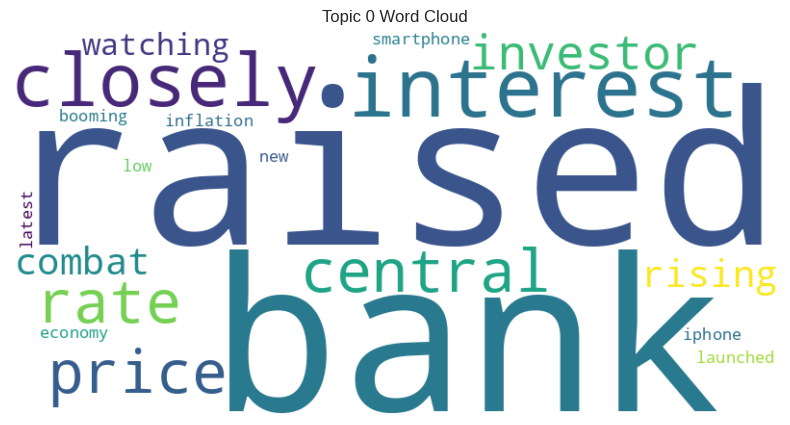

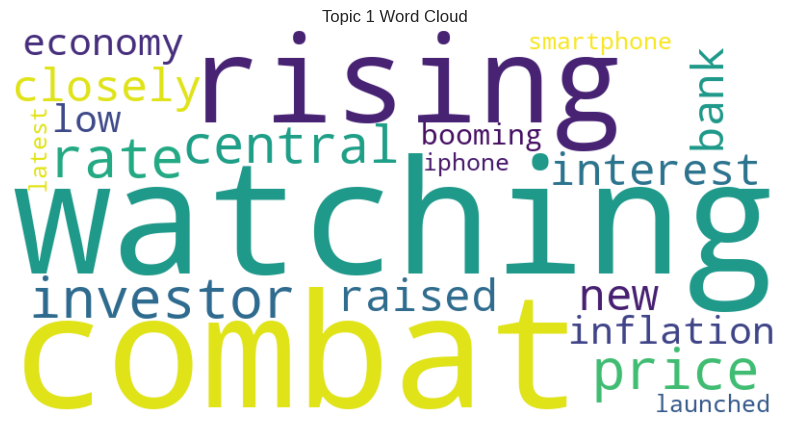

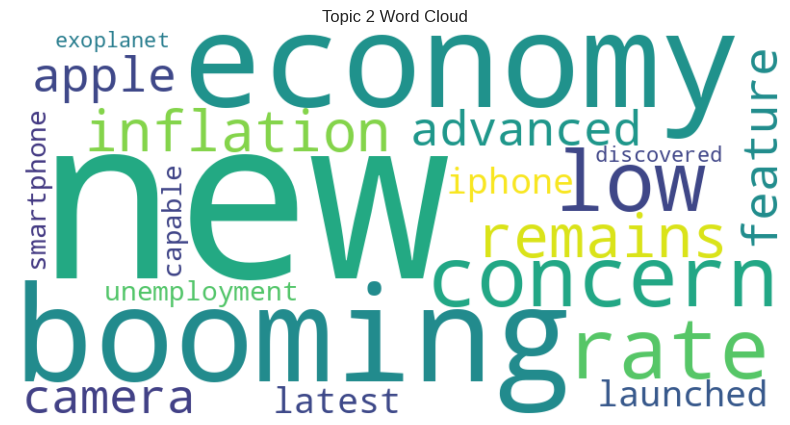

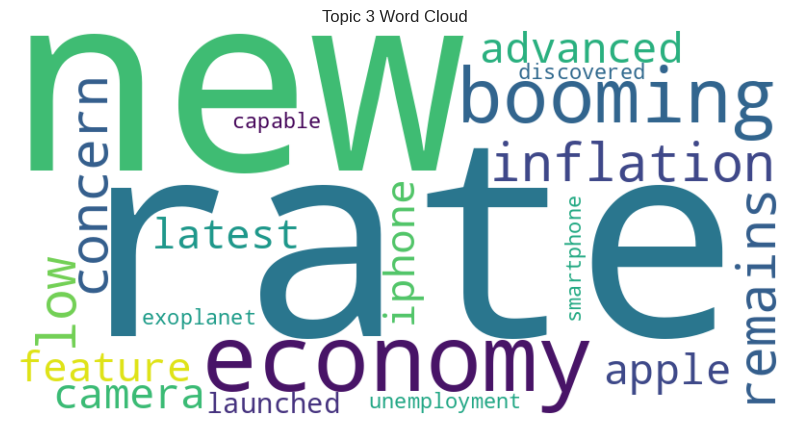

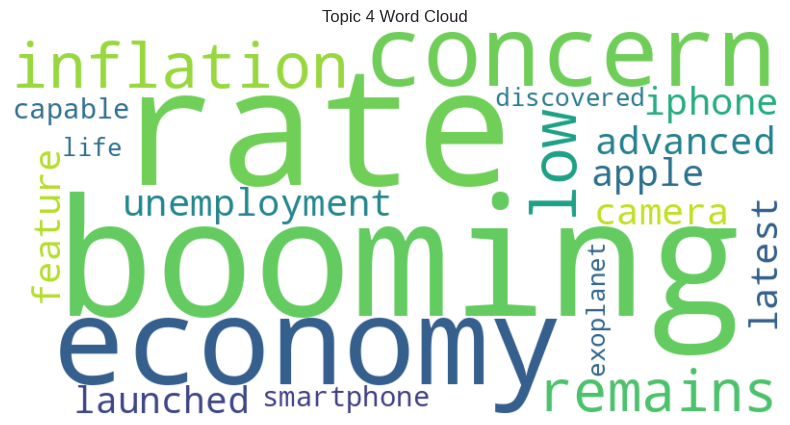

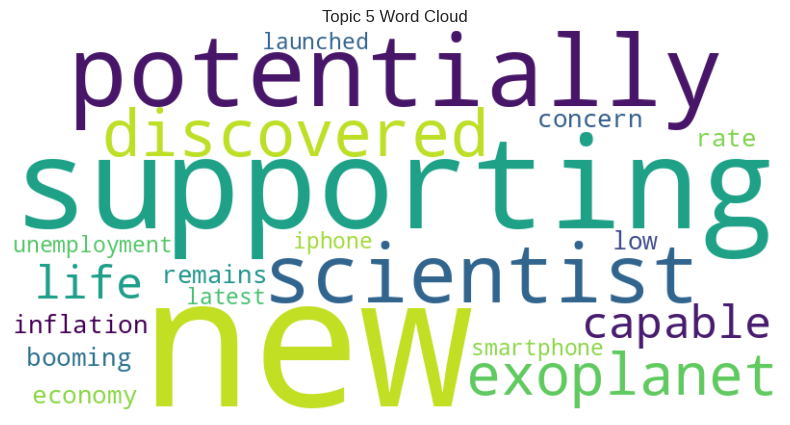

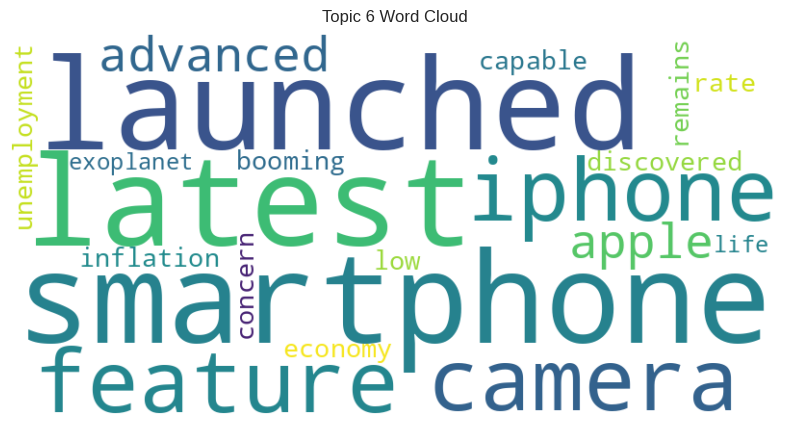

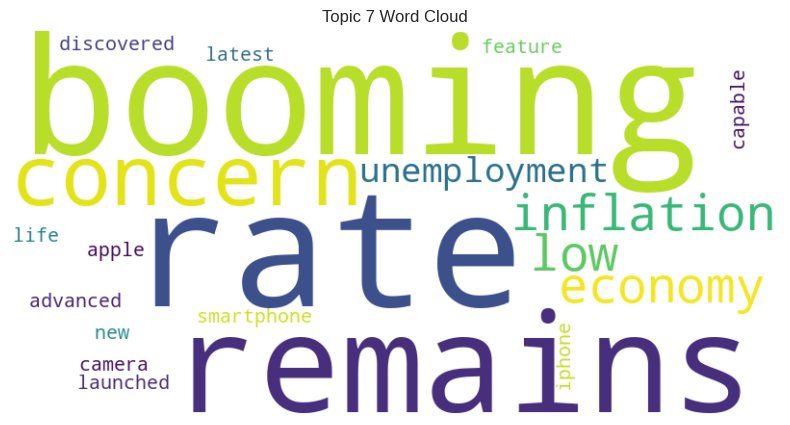

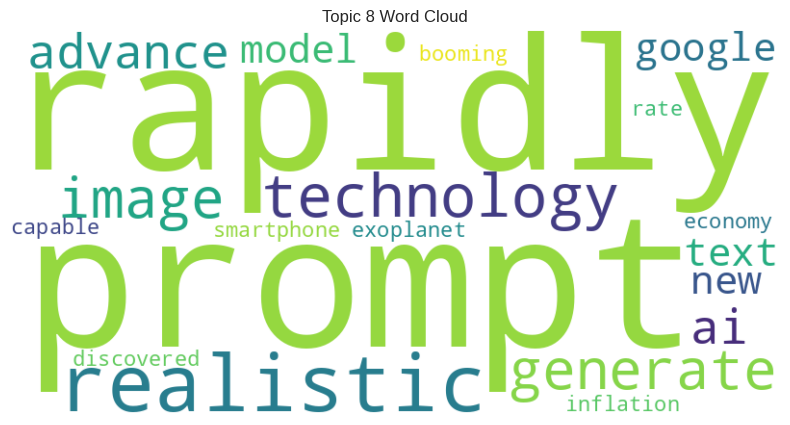

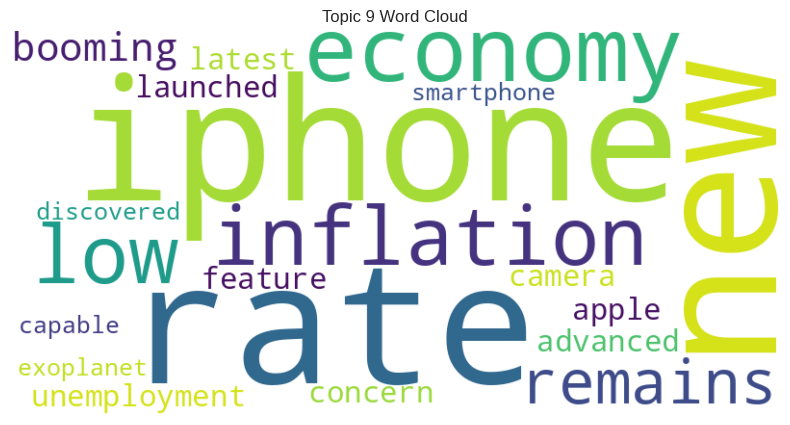

Word clouds for topics displayed.

--- Testing Sentiment Analysis Component ---
  Test 1 PASSED: 'This is a fantastic product, I love it!' -> Label: Positive (Expected: Positive)
  Test 2 PASSED: 'The service was terrible and I'm very disappointed.' -> Label: Negative (Expected: Negative)
  Test 3 FAILED: 'The report states facts about the market trends.' -> Label: Neutral (Expected: Neutral)
    Polarity: 0.0 (Expected ~0.2), Subjectivity: 0.0 (Expected ~0.2)
  Test 4 FAILED: 'It's okay, not great, not bad.' -> Label: Positive (Expected: Neutral)
    Polarity: 0.15 (Expected ~0.2), Subjectivity: 0.6389 (Expected ~0.2)

--- Testing Entity Extraction Component ---
  PASSED: Found 'Apple' as ORG
  PASSED: Found 'Google' as ORG
  PASSED: Found 'Microsoft' as ORG
  PASSED: Found 'Tim Cook' as PERSON
  PASSED: Found 'Cupertino' as GPE
  PASSED: Found 'California' as GPE

spaCy may split 'iPhone 15' into PRODUCT + CARDINAL.
Entity extraction testing completed.

--- Testing Summarization Comp

{'elapsed_time': 4.962531328201294, 'articles_processed': 10}

In [ ]:
test_suite._prepare_classification_model()
test_suite.test_individual_components()
test_suite.test_integration()
test_suite.test_performance()
# test_suite.test_edge_cases()

The `NewsBot2Evaluator` class is now fully implemented with methods for classification, topic modeling, summarization, and user experience evaluation, as well as a report generation function.

In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module='jupyter_client')

# 📊 System Evaluation and Metrics
class NewsBot2Evaluator:
  """
  Comprehensive evaluation framework for NewsBot 2.0
  """
  def __init__(self, newsbot_system):
    self.newsbot = newsbot_system
    self.core_newsbot = newsbot_system.newsbot
    self.topic_engine = newsbot_system.topic_engine
    self.sentiment_tracker = newsbot_system.sentiment_tracker
    self.summarizer = newsbot_system.summarizer

  def _prepare_classification_model_for_eval(self):
      """Ensures the classification model is ready for evaluation if not already loaded."""
      if self.core_newsbot.best_pipeline is None:
          print("  Preparing a dummy classification model for evaluation if not already loaded...")
          from sklearn.feature_extraction.text import TfidfVectorizer
          from sklearn.naive_bayes import MultinomialNB
          from sklearn.pipeline import Pipeline

          train_texts = [
              "apple announces new iphone launch event", "google search engine updates",
              "microsoft earnings report", "tesla stock goes up",
              "economy showing signs of recovery", "inflation rates rising",
              "health and wellness tips", "new fitness tracker released"
          ]
          train_labels = [
              "Technology", "Technology", "Technology", "Economy",
              "Economy", "Economy", "Health", "Health"
          ]
          dummy_pipeline = Pipeline([('tfidf', TfidfVectorizer(max_features=1000)), ('clf', MultinomialNB(alpha=0.1))])
          dummy_pipeline.fit(train_texts, train_labels)
          self.core_newsbot.best_pipeline = dummy_pipeline
          print("  Dummy classification model prepared for evaluation.")

  def evaluate_classification_performance(self, test_data):
    """
    Evaluate classification accuracy and performance.
    Args:
        test_data (list of tuples): Each tuple is (text, true_label).
    Returns:
        dict: Classification metrics.
    """
    print("\n--- Evaluating Classification Performance ---")
    self._prepare_classification_model_for_eval() # Ensure model is ready

    if self.core_newsbot.best_pipeline is None:
        return {"error": "Classification model not trained or loaded."}

    true_labels = [label for _, label in test_data]
    texts = [text for text, _ in test_data]
    predicted_labels = self.core_newsbot.best_pipeline.predict(texts)

    report = classification_report(true_labels, predicted_labels, output_dict=True)
    accuracy = accuracy_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    print("Classification Report:")
    print(classification_report(true_labels, predicted_labels))

    return {
        "accuracy": accuracy,
        "f1_score_weighted": f1,
        "report": report
    }

  def evaluate_topic_modeling_quality(self, documents, num_topics=5):
    """
    Evaluate topic modeling effectiveness using coherence score.
    Args:
        documents (list of str): List of documents for topic modeling.
        num_topics (int): Number of topics to train for evaluation.
    Returns:
        dict: Topic modeling metrics.
    """
    print("\n--- Evaluating Topic Modeling Quality ---")
    if not documents:
        return {"error": "No documents provided for topic modeling evaluation."}

    # Temporarily create a topic engine to avoid side effects on the main one
    temp_topic_engine = TopicDiscoveryEngine(n_topics=num_topics)
    processed_docs = [temp_topic_engine._preprocess_for_topic_modeling(doc) for doc in documents]
    processed_docs = [doc for doc in processed_docs if doc] # Filter out empty docs

    if not processed_docs:
        return {"error": "No valid documents left after preprocessing for topic modeling."}

    dictionary = gm.corpora.Dictionary(processed_docs)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

    if not corpus:
        return {"error": "Empty corpus after dictionary filtering for topic modeling."}

    # Train LDA model
    lda_model = gm.models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=10, random_state=42)

    # Calculate Coherence Score
    coherence_model_lda = gm.models.CoherenceModel(model=lda_model, texts=processed_docs, dictionary=dictionary, coherence='c_v')
    coherence_lda = coherence_model_lda.get_coherence()

    print(f"Coherence Score for {num_topics} topics: {coherence_lda:.4f}")
    return {"coherence_score": coherence_lda}

  def evaluate_summarization_quality(self, articles_and_summaries):
    """
    Evaluate summarization effectiveness using ROUGE scores.
    Args:
        articles_and_summaries (list of tuples): Each tuple is (original_text, generated_summary, [reference_summary]).
                                                  reference_summary is optional.
    Returns:
        dict: Summarization metrics (ROUGE scores).
    """
    print("\n--- Evaluating Summarization Quality ---")
    if not articles_and_summaries:
        return {"error": "No data provided for summarization evaluation."}

    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    all_rouge_scores = {'rouge1': {'fmeasure': [], 'precision': [], 'recall': []},
                        'rouge2': {'fmeasure': [], 'precision': [], 'recall': []},
                        'rougeL': {'fmeasure': [], 'precision': [], 'recall': []}}

    for item in articles_and_summaries:
        original_text, generated_summary = item[0], item[1]
        reference_summary = item[2] if len(item) > 2 else original_text # Use original as reference if none provided

        scores = scorer.score(reference_summary, generated_summary)
        for rouge_type, metrics in scores.items():
            all_rouge_scores[rouge_type]['fmeasure'].append(metrics.fmeasure)
            all_rouge_scores[rouge_type]['precision'].append(metrics.precision)
            all_rouge_scores[rouge_type]['recall'].append(metrics.recall)

    avg_rouge_scores = {}
    for rouge_type, metrics_list in all_rouge_scores.items():
        avg_rouge_scores[rouge_type] = {
            'fmeasure': np.mean(metrics_list['fmeasure']),
            'precision': np.mean(metrics_list['precision']),
            'recall': np.mean(metrics_list['recall'])
        }

    print("Average ROUGE Scores:")
    for rt, metrics in avg_rouge_scores.items():
        print(f"  {rt.upper()}: F1={metrics['fmeasure']:.4f}, P={metrics['precision']:.4f}, R={metrics['recall']:.4f}")

    return avg_rouge_scores

  def evaluate_user_experience(self, user_interactions):
    """
    Evaluate conversational interface effectiveness. This is largely qualitative.
    Args:
        user_interactions (list of dicts): Logs of user queries, system responses, and user feedback.
    Returns:
        dict: User experience metrics (often qualitative or aggregated from surveys/logs).
    """
    print("\n--- Evaluating User Experience ---")
    if not user_interactions:
        return {"info": "No user interactions provided for evaluation."}

    # This is a placeholder for real UX evaluation, which would involve:
    # 1. Analyzing logs for task completion rates (e.g., did the user get a summary when asked?)
    # 2. Sentiment analysis of user feedback/queries.
    # 3. Manual review of conversations.
    # 4. A/B testing different response strategies.

    # For demonstration, we'll just count interactions and unique users.
    num_interactions = len(user_interactions)
    unique_users = len(set(i.get('user_id') for i in user_interactions if 'user_id' in i))

    print(f"Total user interactions logged: {num_interactions}")
    print(f"Unique users identified: {unique_users}")
    print("Further qualitative analysis of interaction logs and user surveys would be necessary for a full UX evaluation.")

    return {
        "total_interactions": num_interactions,
        "unique_users": unique_users,
        "note": "Full UX evaluation requires qualitative analysis and potentially user surveys."
    }

  def generate_evaluation_report(self, classification_data=None, topic_data=None, summarization_data=None, user_data=None):
    """
    Generate comprehensive evaluation report by calling individual evaluation functions.
    Args:
        classification_data, topic_data, summarization_data, user_data: Data needed for each evaluation.
    Returns:
        dict: A compiled report of all evaluation results.
    """
    print("\n===== Generating Comprehensive Evaluation Report =====")
    report = {}

    if classification_data:
        report['classification_evaluation'] = self.evaluate_classification_performance(classification_data)

    elif topic_data:
        report['topic_modeling_evaluation'] = self.evaluate_topic_modeling_quality(topic_data)

    elif summarization_data:
        report['summarization_evaluation'] = self.evaluate_summarization_quality(summarization_data)

    elif user_data:
        report['user_experience_evaluation'] = self.evaluate_user_experience(user_data)

    # Add more evaluation types as they are implemented

    print("\nEvaluation Report Generated.")
    return report

# Instantiate your evaluation framework
evaluator = NewsBot2Evaluator(newsbot2)
print("📊 Evaluation framework ready for implementation!")

📊 Evaluation framework ready for implementation!


# Example Articles for testing
articles = [
    "Apple Inc. announced today that Tim Cook, its CEO, introduced the new iPhone 15 in Cupertino, California.",
    "The CEO of Google, Sundar Pichai, spoke about AI advancements at a conference in Mountain View. Google competes with Apple in many markets.",
    "Microsoft's Satya Nadella mentioned a partnership with OpenAI. OpenAI is known for its GPT models."
]

# 1. Test extract_entities
print("\n--- Testing Entity Extraction ---")
for i, article in enumerate(articles):
    print(f"\nArticle {i+1}:")
    entities = entity_mapper.extract_entities(article)
    for entity_type, entity_list in entities.items():
        print(f"  {entity_type}: {', '.join(entity_list)}")

# 2. Test extract_relationships
print("\n--- Testing Relationship Extraction ---")
all_relationships = []
for i, article in enumerate(articles):
    print(f"\nArticle {i+1}:")
    relationships = entity_mapper.extract_relationships(article)
    if relationships:
        for rel in relationships:
            print(f"  ({rel['head']} [{rel['head_type']}] -- {rel['relation']} --> {rel['tail']} [{rel['tail_type']}])")
            all_relationships.append(rel)
    else:
        print("  No relationships found.")

# 3. Test build_knowledge_graph
print("\n--- Testing Knowledge Graph Building ---")
kg = entity_mapper.build_knowledge_graph(articles)
print("\nKnowledge Graph (sample connections):")
for entity, connections in list(kg.items())[:5]: # Display first 5 entities and their connections
    print(f"  {entity}:")
    for conn in connections[:2]: # Display first 2 connections for each entity
        print(f"    - {conn['relation']} -> {conn['target']}")

# 4. Test find_entity_connections
print("\n--- Testing Entity Connection Finding ---")
connections = entity_mapper.find_entity_connections("Tim Cook", "iPhone 15")
print(f"\nConnections between 'Tim Cook' and 'iPhone 15': {connections}")

connections = entity_mapper.find_entity_connections("Apple Inc.", "Google")
print(f"\nConnections between 'Apple Inc.' and 'Google': {connections}")

connections = entity_mapper.find_entity_connections("Microsoft", "GPT models")
print(f"\nConnections between 'Microsoft' and 'GPT models': {connections}")

connections = entity_mapper.find_entity_connections("NonExistentEntity", "Google")
print(f"\nConnections between 'NonExistentEntity' and 'Google': {connections}")